In [1]:
#IMPORTS
from python_model.bpsk.dsp import tx  
import matplotlib.pyplot as plt
import numpy as np
import math

## Understanding $E_b/N_0$ 

### Average power
$$
P = E/T
$$
*E is energy and T is the Period*

Rearrange: $E=PT$


### Energy Per bit
$$E_b = P T_b$$
*this come out to be Joules* 

### Thermal Noise
To describe thermal noise power with $W/Hz$ which is equivalent to Joules
This can be described as 
$$P_n = N_0 B$$
*$P_n$ is noise power and $N_0$ is noise power per Hz of bandwidth and B is bandwidth* 

### Relation ship to SNR and how to use it
To use this idea a ratio is needed. This ratio is Energy per bit vs. Noise present in the receiver
$$E_B/N_0$$

This relates to SNR by 
$$E_b = PT_b$$
$$T_b = 1/R_b$$
*$R_b$ is bit rate*
$$E_b = P/R_b$$

Now create the ratio
$$E_b/N_0 = P/R_b*N_0$$

if: $P_n = N_0*B$ then $N_0=P_n/B$

$$ E_b/N_0=P/P_N * B/R_b $$
or 
$$E_b/N_0 = SNR * B/R_b$$

### BPSK Example
    This example will use 0-> -1 and 1 -> +1 to repersent its bits for this example.
    Since the amplitude for the signal are +/- 1 
    For BPSK 1 symbol equals 1 bit so E per bit and enery per symbol are equal.
    Looking at $E_b/N_0= 6 dB$


### How much should engery be divided?


This comes from:

$k=log_2(M)$

where:

M = constellation size

For different modulations:

|Modulation|M|$k=log_2(M)$|5
|BPSK|2|1|
|QPSK|4|2
|8-PSK|8|3
|16-QAM|16|4
    
### Solving for $N_0$
$$E_b/N_0=E_b/N_0$$
*Cross multiple*
$$E_b * N_0 = E_b * N_0$$
$$N_0 = \frac{E_bN_0}{E_b} $$
$$N_0 = \frac{E_b}{E_b/N_0}$$
*$E_b = E_s/k$ energy for a bit is found by dividing the signal engery by the number of bits per symbol*
$$N_0 = \frac{E_s}{kE_b/N_0}



# Level power to desired SNR

In [2]:


Eb_N0dB = 10
Eb_N0 = 10**(Eb_N0dB/10) #Linear value for Eb/N0
Es = 1 #Normalize constilation np.mean(np.abs(signal**2)) for passband 
k = 1 #For one bit per symbol
N_0 = Es/k*Eb_N0
N = 100000
noise_scale_factor = np.sqrt(N_0/2)
noise = noise_scale_factor * (np.random.randn(N)+1j * np.random.randn(N))



# Baseband BER Simulation

-2 12947 100000
-1 10352 100000
0 7907 100000
1 5541 100000
2 3785 100000
3 2158 100000
4 1281 100000
5 595 100000
6 230 100000
7 150 200000
8 118 600000
9 102 2600000
10 99 25900000
11 10 50000000
12 1 50000000


Text(0.5, 1.0, 'BPSK BER Waterfall Plot')

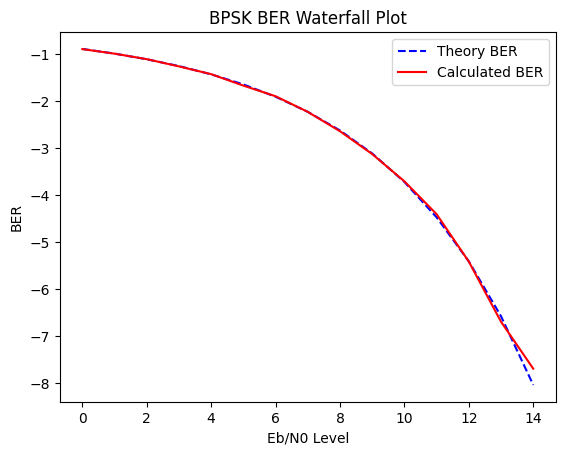

In [7]:
wave = tx('13',1,20,10000,100000)


EbN0dB = np.arange(-2,13)
k = 1 #1 for BPSK and 2 for QPSK
signal = 0
block_size = 100000
max_error_bit = 100
ber_theory = []
ber = []

for EbN0 in EbN0dB:
    #produce noise at power level
    #convert to linear power
    Eb_N0 = 10**(EbN0/10)
    ber_theory.append(np.log10(0.5*math.erfc(np.sqrt(Eb_N0))))
    max_bits = int(np.ceil(max_error_bit / (0.5*math.erfc(np.sqrt(Eb_N0)))))
    max_bits = min(max_bits, int(5e7))
    max_bits
    bit_errors=0
    bit_processed=0
    while bit_errors < max_error_bit and bit_processed < max_bits:
        signal = 2*np.random.randint(0,2,block_size)-1 #produce random bits
        Es = np.mean(np.abs(signal)**2) #convert to signal power
        N0 = Es/(k*Eb_N0) #Noise per Hz bin
        noise_scale_factor = np.sqrt(N0/2) #Creating scaling factor for correct SNR
        noise = noise_scale_factor * (np.random.randn(block_size)+1j * np.random.randn(block_size))

        #Create noise signal r=s+n
        r = signal+noise
        #Grab the angle of the bit and determine if the abs(signal) is less than pi.
        #this tells use which side of the Unit circle we are on. 
        r_processed = np.where(np.abs(np.angle(r)) < np.pi/2,1,-1) 
        #Determine if the processed signal is 
        bit_errors += len(signal)-np.sum(np.where(r_processed==signal,1,0))
        bit_processed += len(signal)

    print(EbN0,bit_errors,bit_processed)
    ber.append(np.log10(bit_errors/bit_processed))    



# 2. Call the plot function for each line
plt.plot(ber_theory, label="Theory BER", color="blue", linestyle="--")
plt.plot(ber, label="Calculated BER", color="red", linestyle="-")
plt.legend()
plt.xlabel('Eb/N0 Level')
plt.ylabel('BER')
plt.title('BPSK BER Waterfall Plot')

## Passband BER Simulation

In [ ]:
#Loop through Eb/N0 levels
#Determine correct noise level
#create noise array with determined noise
#Create random Baseband bits
#DUC signal
#Combine DUC signal with noise 
#DDC convert out passband signal

## Normalizing Frequency

The way to understand the normalized frequency concept is to understand how the carrier signal is produced.

Looking at how the carrier signal is created $$Carrier=e^{2\pi f_c t}$$

The variable we want to look at is *t*

Normally the t is produced by the following formula $$t=n/F_s$$ *Where $n=\{1,2,3,...,number\_of\_samples\}$ and $F_s$ is the sampling frequency*


Combining these equations $$Carrier = e^{2\pi f_c \frac{n}{F_s}}$$ $$Carrier = e^{2\pi n \frac{f_c}{F_s}}$$

Looking at $$\frac{f_c}{F_s}$$ *$f_c$ is the carrier frequency and $F_s$ is the sampling rate*

This can be treated as a ratio from 0-1. When $f$ is equal to 1 then the signal is operating at the sampling rate. If $f$ is set to 0.5 the signal is operating at the nyquist rate. setting $f$ to 0.1 is a good place 

-2 12947 100000
-1 10352 100000
0 7907 100000
1 5541 100000
2 3785 100000
3 2158 100000
4 1281 100000
5 595 100000
6 230 100000
7 150 200000
8 118 600000
9 102 2600000
10 99 25900000
11 10 50000000
12 1 50000000


Text(0.5, 1.0, 'BPSK BER Waterfall Plot')

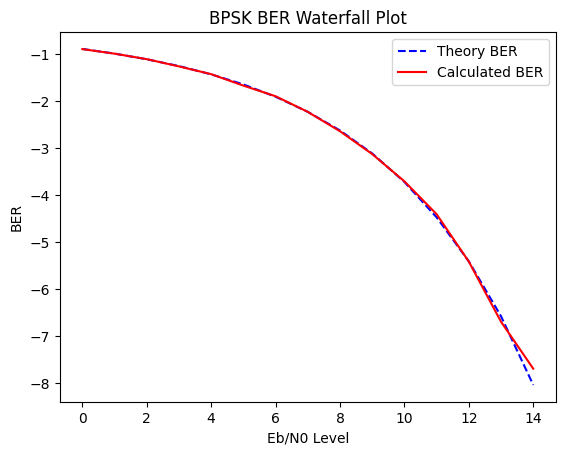

In [ ]:
EbN0dB = np.arange(-2,13)
k = 1 #1 for BPSK and 2 for QPSK
signal = 0
block_size = 100000
max_error_bit = 100
ber_theory = []
ber = []
bits_per_chip = 10
carrier = 0.1 #normalize frequency with 0 at DC and 1 at sampling rate.
n = np.arange(0,block_size)
for EbN0 in EbN0dB:
    #produce noise at power level
    #convert to linear power
    Eb_N0 = 10**(EbN0/10)
    ber_theory.append(np.log10(0.5*math.erfc(np.sqrt(Eb_N0))))
    max_bits = int(np.ceil(max_error_bit / (0.5*math.erfc(np.sqrt(Eb_N0)))))
    max_bits = min(max_bits, int(5e7))
    bit_errors=0
    bit_processed=0
    while bit_errors < max_error_bit and bit_processed < max_bits:
        signal = 2*np.random.randint(0,2,block_size)-1 #produce random bits
        signal = np.repeat(signal,bits_per_chip)
        signal = signal * np.exp(2*np.pi*carrier*n)
        Es = np.mean(np.abs(signal)**2) #convert to signal power
        N0 = Es/(k*Eb_N0) #Noise per Hz bin
        noise_scale_factor = np.sqrt(N0/2) #Creating scaling factor for correct SNR
        noise = noise_scale_factor * (np.random.randn(block_size)+1j * np.random.randn(block_size))

        #Create noise signal r=s+n
        r = signal+noise


        #Grab the angle of the bit and determine if the abs(signal) is less than pi.
        #this tells use which side of the Unit circle we are on. 
        r_processed = np.where(np.abs(np.angle(r)) < np.pi/2,1,-1) 
        #Determine if the processed signal is 
        bit_errors += len(signal)-np.sum(np.where(r_processed==signal,1,0))
        bit_processed += len(signal)

    ber.append(np.log10(bit_errors/bit_processed))    



# 2. Call the plot function for each line
plt.plot(ber_theory, label="Theory BER", color="blue", linestyle="--")
plt.plot(ber, label="Calculated BER", color="red", linestyle="-")
plt.legend()
plt.xlabel('Eb/N0 Level')
plt.ylabel('BER')
plt.title('BPSK BER Waterfall Plot')